In [1]:
import csv
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset


class FrameCSVDataset(Dataset):
    """
    PyTorch Dataset that reads (filename,left,right) from a CSV and builds
    temporal windows of length seq_len ending at the current frame.
    Pads missing past frames with zeros on the left.

    Output:
      X: (T, 3, H, W) float32 in [0,1]
      y: int64 sparse label: 0=Left, 1=None, 2=Right
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        seq_len=128,
        max_none_per_epoch=0,   # 0 => exclude None, -1 => include all
        mask_boxes=None,        # list of (xmin,ymin,xmax,ymax)
        image_size=(224, 224),
        shuffle=True,
        debug_zero_right=False,
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.image_size = tuple(image_size)
        self.shuffle = bool(shuffle)
        self.debug_zero_right = debug_zero_right

        # Load CSV
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Sort to preserve temporal order
        rows = sorted(rows, key=lambda r: r["filename"])

        self.filenames = [r["filename"] for r in rows]
        self.lefts = np.array([int(r["left"]) for r in rows], dtype=np.int32)
        self.rights = np.array([int(r["right"]) for r in rows], dtype=np.int32)

        # Label indices: 0=Left, 1=None, 2=Right
        self.y_idx = np.zeros(len(rows), dtype=np.int64)
        for i in range(len(rows)):
            l = self.lefts[i]
            r = self.rights[i]
            none = 1 if (l == r) else 0
            if l == 1 and r == 0:
                self.y_idx[i] = 0
            elif none == 1:
                self.y_idx[i] = 1
            else:
                self.y_idx[i] = 2

        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Epoch sampling (call this once per epoch from training loop)
    # ------------------------------------------------------------------
    def _build_epoch_indices(self):
        all_indices = list(range(len(self.filenames)))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            random.shuffle(none_indices)
            chosen_none = none_indices[: self.max_none_per_epoch]

        self.epoch_indices = non_none_indices + chosen_none

        if self.shuffle:
            random.shuffle(self.epoch_indices)

    def on_epoch_start(self):
        """Call this at the start of each epoch."""
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Dataset API
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.epoch_indices)

    def _load_frame(self, index):
        img_path = self.frames_dir / self.filenames[index]

        with Image.open(img_path) as im:
            im = im.convert("RGB")

            if self.mask_boxes:
                im_arr = np.array(im, dtype=np.uint8)
                for xmin, ymin, xmax, ymax in self.mask_boxes:
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(im_arr.shape[1], xmax)
                    ymax = min(im_arr.shape[0], ymax)
                    if xmax > xmin and ymax > ymin:
                        im_arr[ymin:ymax, xmin:xmax, :] = 0
                im = Image.fromarray(im_arr)

            im = im.resize((self.image_size[1], self.image_size[0]))

            x = np.asarray(im, dtype=np.float32) / 255.0
            x = torch.from_numpy(x).permute(2, 0, 1)  # (3,H,W)

        return x
    
    def __getitem__(self, idx):
        cur_idx = self.epoch_indices[idx]

        T = self.seq_len
        C, H, W = 3, self.image_size[0], self.image_size[1]

        label = int(self.y_idx[cur_idx])  # 0=Left, 1=None, 2=Right

        # --------------------------------------------------
        # DEBUG MODE: zero-out RIGHT class frames
        # --------------------------------------------------
        if self.debug_zero_right and label == 2:
            X = torch.zeros((T, C, H, W), dtype=torch.float32)
            y = torch.tensor(label, dtype=torch.long)
            return X, y

        # --------------------------------------------------
        # Normal path
        # --------------------------------------------------
        X = torch.zeros((T, C, H, W), dtype=torch.float32)

        seq_start = cur_idx - (T - 1)

        for t in range(T):
            src_idx = seq_start + t
            if src_idx < 0:
                continue
            X[t] = self._load_frame(src_idx)

        y = torch.tensor(label, dtype=torch.long)
        return X, y


    # def __getitem__(self, idx):
    #     cur_idx = self.epoch_indices[idx]

    #     T = self.seq_len
    #     C, H, W = 3, self.image_size[0], self.image_size[1]

    #     X = torch.zeros((T, C, H, W), dtype=torch.float32)

    #     seq_start = cur_idx - (T - 1)

    #     for t in range(T):
    #         src_idx = seq_start + t
    #         if src_idx < 0:
    #             continue
    #         X[t] = self._load_frame(src_idx)

    #     y = torch.tensor(self.y_idx[cur_idx], dtype=torch.long)

    #     return X, y

    

import os
import random
from pathlib import Path
from typing import Optional, List, Tuple

import numpy as np
import torch
from torch.utils.data import Dataset
import tensorflow as tf


class FrameTFRecordUInt8SequenceDataset(Dataset):
    """
    Like FrameTFRecordUInt8SequenceDataset but caches a TFRecord byte-offset index
    to disk so startup is fast after first run.

    Cache file is saved next to TFRecord as:
      <tfrecord_path>.idx.npz

    TFRecord schema expected:
      image_raw (bytes), height,width,channels (int64), left,right (int64), filename (optional)
    """

    def __init__(
        self,
        tfrecord_path,
        seq_len=128,
        max_none_per_epoch=0,   # 0 => exclude None, -1 => include all
        mask_boxes=None,
        image_size=(224, 224),
        shuffle=True,
        debug_zero_right=False,
        cache_index=True,
        frame_stride: int = 1,   # <-- NEW
        # keys
        key_image_raw="image_raw",
        key_h="height",
        key_w="width",
        key_c="channels",
        key_left="left",
        key_right="right",
        key_filename="filename",
        seed=42
    ):
        self.tfrecord_path = str(Path(tfrecord_path))
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.image_size = tuple(image_size)
        self.shuffle = bool(shuffle)
        self.debug_zero_right = bool(debug_zero_right)

        self.key_image_raw = key_image_raw
        self.key_h = key_h
        self.key_w = key_w
        self.key_c = key_c
        self.key_left = key_left
        self.key_right = key_right
        self.key_filename = key_filename

        self.cache_index = bool(cache_index)
        self.index_path = self.tfrecord_path + ".idx.npz"
        self.frame_stride = max(1, int(frame_stride))

        self.seed = int(seed)
        self._epoch = 0

        # Feature specs (for metadata only; image_raw decoding happens on-demand)
        self._base_feature_spec = {
            self.key_image_raw: tf.io.FixedLenFeature([], tf.string),
            self.key_h: tf.io.FixedLenFeature([], tf.int64),
            self.key_w: tf.io.FixedLenFeature([], tf.int64),
            self.key_c: tf.io.FixedLenFeature([], tf.int64),
            self.key_left: tf.io.FixedLenFeature([], tf.int64),
            self.key_right: tf.io.FixedLenFeature([], tf.int64),
        }

        # Load or build index
        if self.cache_index and os.path.exists(self.index_path):
            self._load_index()
        else:
            self._build_and_cache_index()

        # Build epoch sampling list
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Index building / loading
    # ------------------------------------------------------------------
    def _detect_filename_present(self) -> bool:
        ds = tf.data.TFRecordDataset([self.tfrecord_path])
        first = None
        for raw in ds.take(1):
            first = raw
        if first is None:
            raise ValueError(f"No records in TFRecord: {self.tfrecord_path}")

        spec = dict(self._base_feature_spec)
        spec[self.key_filename] = tf.io.FixedLenFeature([], tf.string)

        try:
            ex = tf.io.parse_single_example(first, spec)
            _ = ex[self.key_filename].numpy()
            return True
        except Exception:
            return False

    def _parse_meta(self, raw_example, has_filename: bool):
        spec = dict(self._base_feature_spec)
        if has_filename:
            spec[self.key_filename] = tf.io.FixedLenFeature([], tf.string)

        ex = tf.io.parse_single_example(raw_example, spec)

        h = int(ex[self.key_h].numpy())
        w = int(ex[self.key_w].numpy())
        c = int(ex[self.key_c].numpy())
        left = int(ex[self.key_left].numpy())
        right = int(ex[self.key_right].numpy())

        fname = ""
        if has_filename:
            try:
                fname = ex[self.key_filename].numpy().decode("utf-8")
            except Exception:
                fname = ""

        return h, w, c, left, right, fname

    def _build_and_cache_index(self):
        has_filename = self._detect_filename_present()
        self.has_filename = has_filename

        offsets = []
        h_list, w_list, c_list = [], [], []
        lefts, rights = [], []
        fnames = []

        # We read the TFRecord file in binary to get byte offsets.
        # TFRecord format is record-based; tf.compat.v1.io.tf_record_iterator streams records,
        # but doesn't expose offsets. We track offsets by reading the file ourselves
        # and using tf_record_iterator to parse metadata in parallel.

        # Practical approach: iterate raw records with tf_record_iterator AND
        # compute offsets by scanning the file in the same order.
        # We'll do a single-pass manual TFRecord scanner to record offsets.
        #
        # TFRecord record layout:
        #   uint64 length
        #   uint32 masked_crc(length)
        #   byte[length] data
        #   uint32 masked_crc(data)
        #
        # We'll parse these with numpy from the file.

        import struct

        def masked_crc32c(data: bytes) -> int:
            # Not needed for reading offsets, we can ignore CRC
            return 0

        with open(self.tfrecord_path, "rb") as f:
            pos = 0
            record_idx = 0

            while True:
                header = f.read(12)  # 8 len + 4 len_crc
                if not header:
                    break
                if len(header) != 12:
                    raise ValueError("Corrupt TFRecord (incomplete header)")

                length = struct.unpack("<Q", header[:8])[0]
                # skip length crc (4 bytes) already read

                data = f.read(length)
                if len(data) != length:
                    raise ValueError("Corrupt TFRecord (incomplete data)")

                footer = f.read(4)  # data crc
                if len(footer) != 4:
                    raise ValueError("Corrupt TFRecord (incomplete footer)")

                # Record start offset is 'pos'
                offsets.append(pos)

                # Parse metadata from 'data'
                h, w, c, left, right, fname = self._parse_meta(data, has_filename)
                h_list.append(h); w_list.append(w); c_list.append(c)
                lefts.append(left); rights.append(right)
                fnames.append(fname)

                pos = f.tell()
                record_idx += 1

                if record_idx % 20000 == 0:
                    print(f"Indexed {record_idx:,} records...")

        offsets = np.array(offsets, dtype=np.int64)
        h_arr = np.array(h_list, dtype=np.int32)
        w_arr = np.array(w_list, dtype=np.int32)
        c_arr = np.array(c_list, dtype=np.int32)
        left_arr = np.array(lefts, dtype=np.int32)
        right_arr = np.array(rights, dtype=np.int32)

        # Labels (0 Left, 1 None, 2 Right)
        y_idx = np.zeros(len(offsets), dtype=np.int64)
        for i in range(len(offsets)):
            l = left_arr[i]
            r = right_arr[i]
            if l == 1 and r == 0:
                y_idx[i] = 0
            elif l == r:
                y_idx[i] = 1
            else:
                y_idx[i] = 2

        # Save cache
        if self.cache_index:
            np.savez_compressed(
                self.index_path,
                offsets=offsets,
                height=h_arr,
                width=w_arr,
                channels=c_arr,
                left=left_arr,
                right=right_arr,
                y_idx=y_idx,
                has_filename=np.array([1 if self.has_filename else 0], dtype=np.int8),
                filename=np.array(fnames, dtype=object),
            )
            print(f"Saved TFRecord index cache: {self.index_path}")

        # Store in memory
        self.offsets = offsets
        self.height = h_arr
        self.width = w_arr
        self.channels = c_arr
        self.lefts = left_arr
        self.rights = right_arr
        self.y_idx = y_idx
        self.filenames = fnames
        

    def _load_index(self):
        data = np.load(self.index_path, allow_pickle=True)
        self.offsets = data["offsets"].astype(np.int64)
        self.height = data["height"].astype(np.int32)
        self.width = data["width"].astype(np.int32)
        self.channels = data["channels"].astype(np.int32)
        self.lefts = data["left"].astype(np.int32)
        self.rights = data["right"].astype(np.int32)
        self.y_idx = data["y_idx"].astype(np.int64)

        has_filename = bool(int(data["has_filename"][0])) if "has_filename" in data else False
        self.has_filename = has_filename

        if "filename" in data:
            self.filenames = data["filename"].tolist()
        else:
            self.filenames = [""] * len(self.offsets)

        print(f"Loaded TFRecord index cache: {self.index_path} ({len(self.offsets):,} records)")

    # ------------------------------------------------------------------
    # Epoch sampling
    # ------------------------------------------------------------------
    # def _build_epoch_indices(self):
    #     all_indices = list(range(len(self.offsets)))

    #     none_indices = [i for i in all_indices if self.y_idx[i] == 1]
    #     non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

    #     if self.max_none_per_epoch == -1:
    #         chosen_none = none_indices
    #     elif self.max_none_per_epoch == 0:
    #         chosen_none = []
    #     else:
    #         random.shuffle(none_indices)
    #         chosen_none = none_indices[: self.max_none_per_epoch]

    #     #self.epoch_indices = non_none_indices + chosen_none
    #     # COMBINE AND SORT to restore time order
    #     self.epoch_indices = sorted(non_none_indices + chosen_none)
    #     if self.shuffle:
    #         random.shuffle(self.epoch_indices)

    def _build_epoch_indices(self):
        N = len(self.offsets)
        all_indices = list(range(N))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        # Deterministic RNG per epoch
        rng = random.Random(self.seed + self._epoch)

        # --- choose None anchors (subsample) ---
        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            if len(none_indices) > self.max_none_per_epoch:
                chosen_none = rng.sample(none_indices, self.max_none_per_epoch)
            else:
                chosen_none = none_indices

        # Combine anchors
        anchors = non_none_indices + chosen_none

        # --- ordering behavior ---
        if self.shuffle:
            # training mode: randomize which anchors you see
            rng.shuffle(anchors)
            self.epoch_indices = anchors
        else:
            # eval/debug mode: keep anchors in increasing time order (skips are allowed)
            self.epoch_indices = sorted(anchors)


    def on_epoch_start(self):
        self._epoch += 1
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Read one record by offset
    # ------------------------------------------------------------------
    def _read_record_at(self, offset: int) -> bytes:
        import struct
        with open(self.tfrecord_path, "rb") as f:
            f.seek(int(offset))
            header = f.read(12)
            if len(header) != 12:
                raise ValueError("Corrupt TFRecord (header)")
            length = struct.unpack("<Q", header[:8])[0]
            data = f.read(length)
            if len(data) != length:
                raise ValueError("Corrupt TFRecord (data)")
            _ = f.read(4)  # footer crc
            return data

    def _decode_image_raw(self, raw_example: bytes):
        # Parse only what we need: image_raw + dims
        spec = {
            self.key_image_raw: tf.io.FixedLenFeature([], tf.string),
            self.key_h: tf.io.FixedLenFeature([], tf.int64),
            self.key_w: tf.io.FixedLenFeature([], tf.int64),
            self.key_c: tf.io.FixedLenFeature([], tf.int64),
        }
        ex = tf.io.parse_single_example(raw_example, spec)
        img_raw = ex[self.key_image_raw].numpy()
        h = int(ex[self.key_h].numpy())
        w = int(ex[self.key_w].numpy())
        c = int(ex[self.key_c].numpy())
        return img_raw, h, w, c

    def _raw_to_tensor(self, img_raw: bytes, h: int, w: int, c: int) -> torch.Tensor:
        arr = np.frombuffer(img_raw, dtype=np.uint8)
        expected = h * w * c
        if arr.size != expected:
            raise ValueError(f"Bad raw size: got {arr.size} expected {expected}")

        arr = arr.reshape((h, w, c))

        if self.mask_boxes:
            arr = arr.copy()
            for xmin, ymin, xmax, ymax in self.mask_boxes:
                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(w, xmax)
                ymax = min(h, ymax)
                if xmax > xmin and ymax > ymin:
                    arr[ymin:ymax, xmin:xmax, :] = 0

        tgt_h, tgt_w = self.image_size
        if (h, w) != (tgt_h, tgt_w):
            t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).float()
            t = torch.nn.functional.interpolate(t, size=(tgt_h, tgt_w), mode="bilinear", align_corners=False)
            t = (t / 255.0).squeeze(0)
            return t

        return torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0

    # ------------------------------------------------------------------
    # Dataset API
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.epoch_indices)

    def __getitem__(self, idx):
        cur_idx = self.epoch_indices[idx]
        label = int(self.y_idx[cur_idx])

        T = self.seq_len
        stride = self.frame_stride
        C, H, W = 3, self.image_size[0], self.image_size[1]

        if self.debug_zero_right and label == 2:
            X = torch.zeros((T, C, H, W), dtype=torch.float32)
            y = torch.tensor(label, dtype=torch.long)
            return X, (y != 1).long()

        X = torch.zeros((T, C, H, W), dtype=torch.float32)

        # Strided sequence anchored at cur_idx (last frame)
        # Example stride=4: cur_idx-(T-1)*4, ..., cur_idx-4, cur_idx
        seq_start = cur_idx - (T - 1) * stride

        for t in range(T):
            src_idx = seq_start + t * stride
            if src_idx < 0 or src_idx >= len(self.offsets):
                continue

            raw = self._read_record_at(self.offsets[src_idx])
            img_raw, h, w, c = self._decode_image_raw(raw)
            X[t] = self._raw_to_tensor(img_raw, h, w, c)

        y = torch.tensor(label, dtype=torch.long)

        # binary target: 1 for Left/Right, 0 for None
        return X, (y != 1).long()





In [2]:
# --- Paths ---
train_csv_path  = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224_controls_extracted.csv"
train_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224"

train_csv_path2  = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_controls_extracted.csv"
train_frames_dir2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224"

val_csv_path   = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224_controls_extracted.csv"
val_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224"

# --- Tf records paths ---
train_tfrecord_path1 = r"D:\Data\Game Dataset\train_data\train_125453s_uint8.tfrecord"
train_tfrecord_path2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_uint8.tfrecord"
val_tfrecord_path    = r"D:\Data\Game Dataset\train_data\val_213242_uint8.tfrecord"

# --- Settings ---
image_size = (224, 224)
batch_size = 16
seq_len = 32
frame_stride = 10
max_none_per_epoch = 30000
debug_zero_right = False
shuffle = True

mask_boxes = [
    (2, 103, 58, 147),      # left HUD region
    (165, 103, 221, 147),   # right HUD region
]
#mask_boxes = None  # disable masking

# --- PyTorch Datasets (replace FrameCSVSequence) ---
train_ds1 = FrameTFRecordUInt8SequenceDataset(
    tfrecord_path=train_tfrecord_path1,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,
    mask_boxes=mask_boxes,
    frame_stride=frame_stride,
    image_size=image_size,
    shuffle=shuffle,
    debug_zero_right=debug_zero_right
)

train_ds2 = FrameTFRecordUInt8SequenceDataset(
   tfrecord_path=train_tfrecord_path2,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,
    mask_boxes=mask_boxes,
    frame_stride=frame_stride,
    image_size=image_size,
    shuffle=shuffle,
    debug_zero_right=debug_zero_right
)

val_ds = FrameTFRecordUInt8SequenceDataset(
    tfrecord_path=val_tfrecord_path,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,   # typical for validation: include all classes
    mask_boxes=mask_boxes,
    frame_stride=frame_stride,
    image_size=image_size,
    shuffle=shuffle,           # typical for validation: deterministic
    debug_zero_right=debug_zero_right
)

# --- DataLoaders ---
# IMPORTANT:
# - Use shuffle=False here because the dataset already performs epoch sampling/shuffling internally.
# - Call dataset.on_epoch_start() at the start of every epoch for train_ds1/train_ds2.
train_loader1 = torch.utils.data.DataLoader(train_ds1, batch_size=batch_size, shuffle=False)
train_loader2 = torch.utils.data.DataLoader(train_ds2, batch_size=batch_size, shuffle=False)
val_loader    = torch.utils.data.DataLoader(val_ds,  batch_size=batch_size, shuffle=False)

# --- Example per-epoch hook (call in your training loop) ---
# for epoch in range(num_epochs):
#     train_ds1.on_epoch_start()
#     train_ds2.on_epoch_start()
#     # val_ds.on_epoch_start()  # usually not needed for val
#     ...


Loaded TFRecord index cache: D:\Data\Game Dataset\train_data\train_125453s_uint8.tfrecord.idx.npz (115,996 records)
Loaded TFRecord index cache: D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_uint8.tfrecord.idx.npz (238,023 records)
Loaded TFRecord index cache: D:\Data\Game Dataset\train_data\val_213242_uint8.tfrecord.idx.npz (80,578 records)


In [3]:
X, y = train_ds1[0]
print(X.shape, X.dtype, y)
print("min/max:", X.min().item(), X.max().item())
print("mean/std approx:", X.mean().item(), X.std().item())

torch.Size([10, 3, 224, 224]) torch.float32 tensor(0)
min/max: 0.0 1.0
mean/std approx: 0.1307298243045807 0.21326862275600433


In [16]:
train_ds1.__getitem__(78)[0] * 255.0

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
        

In [ ]:
train_ds1.shuffle = False
train_ds1.on_epoch_start()

for i in range(20):
    cur_idx = train_ds1.epoch_indices[i]
    print(i, cur_idx, train_ds1.filenames[cur_idx], )

0 13 frame_000889_t_000015150021us.jpg
1 15 frame_000891_t_000015184105us.jpg
2 16 frame_000892_t_000015201146us.jpg
3 25 frame_000901_t_000015354521us.jpg
4 29 frame_000905_t_000015422688us.jpg
5 31 frame_000907_t_000015456771us.jpg
6 39 frame_000915_t_000015593104us.jpg
7 41 frame_000917_t_000015627187us.jpg
8 42 frame_000918_t_000015644229us.jpg
9 52 frame_000928_t_000015814645us.jpg
10 59 frame_000935_t_000015933937us.jpg
11 62 frame_000938_t_000015985062us.jpg
12 68 frame_000944_t_000016087312us.jpg
13 72 frame_000948_t_000016155478us.jpg
14 77 frame_000953_t_000016240686us.jpg
15 94 frame_000970_t_000016530394us.jpg
16 99 frame_000975_t_000016615603us.jpg
17 110 frame_000986_t_000016803061us.jpg
18 114 frame_000990_t_000016871227us.jpg
19 115 frame_000991_t_000016888269us.jpg


In [3]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import torch


import math
import random
import numpy as np
import torch
import matplotlib.pyplot as plt


def visualize_sequence_torch(
    dataset_or_loader,
    max_frames_to_show=32,
    max_cols=8,
    figsize_per_cell=(2.5, 2.5),
    cls_map=None,
    denorm=None,
    random_sample=True,
    dataset_index=0,
    batch_index=0,
    sample_in_batch=0,
    seed=None,
):
    """
    Visualize a temporal sample from a PyTorch Dataset or DataLoader.

    Works with:
      - Dataset returning: X (T,C,H,W) and y (int/0-d tensor) OR (X,y,...) extra fields ignored
      - DataLoader returning: X (B,T,C,H,W) and y (B,) OR extra fields ignored

    Args:
      dataset_or_loader: torch.utils.data.Dataset or DataLoader
      max_frames_to_show: cap frames visualized
      max_cols: max columns in grid
      figsize_per_cell: per-cell size for matplotlib
      cls_map: {0:"L", 1:"N", 2:"R"} mapping
      denorm: optional callable to undo normalization per frame tensor
              signature: denorm(frame_t: torch.Tensor) -> torch.Tensor (C,H,W)
      random_sample: if True, pick a random dataset index (or random item in a batch).
                    if False, use dataset_index (Dataset) or (batch_index, sample_in_batch) (DataLoader)
      dataset_index: used when random_sample=False and input is a Dataset-like object
      batch_index: used when random_sample=False and input is a DataLoader-like object (which batch to take)
      sample_in_batch: used when random_sample=False and input is DataLoader-like (which sample inside that batch)
      seed: optional random seed for reproducible selection

    Notes:
      - Assumes pixel range [0,1] unless denorm is provided.
      - The supervised label corresponds to the LAST frame in the sequence.
    """
    if cls_map is None:
        cls_map = {0: "L", 1: "N", 2: "R"}

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Helper: allow Dataset/DataLoader to return extra fields (fname, idx, etc.)
    def _unpack_xy(batch_or_item):
        if isinstance(batch_or_item, (list, tuple)):
            if len(batch_or_item) < 2:
                raise ValueError("Expected at least (X, y) in returned data.")
            return batch_or_item[0], batch_or_item[1]
        return batch_or_item  # will error later

    # -----------------------------
    # Sample retrieval
    # -----------------------------
    is_dataloader_like = hasattr(dataset_or_loader, "__iter__") and not hasattr(dataset_or_loader, "__getitem__")

    if is_dataloader_like:
        loader = dataset_or_loader

        it = iter(loader)
        batch = None
        if random_sample:
            batch = next(it)
            X, y = _unpack_xy(batch)

            if not (isinstance(X, torch.Tensor) and X.ndim == 5):
                raise ValueError("Expected DataLoader to yield X with shape (B,T,C,H,W).")

            B = X.shape[0]
            sample_idx = random.randint(0, B - 1)
            frames = X[sample_idx]  # (T,C,H,W)
            y_s = y[sample_idx]
            batch_info = "batch=0"
            sample_info = f"sample_in_batch={sample_idx}"
        else:
            # advance to the requested batch_index
            for _ in range(batch_index + 1):
                batch = next(it)
            X, y = _unpack_xy(batch)

            if not (isinstance(X, torch.Tensor) and X.ndim == 5):
                raise ValueError("Expected DataLoader to yield X with shape (B,T,C,H,W).")

            B = X.shape[0]
            if not (0 <= sample_in_batch < B):
                raise IndexError(f"sample_in_batch={sample_in_batch} out of range for batch size {B}")

            frames = X[sample_in_batch]
            y_s = y[sample_in_batch]
            batch_info = f"batch={batch_index}"
            sample_info = f"sample_in_batch={sample_in_batch}"
            sample_idx = sample_in_batch

    else:
        ds = dataset_or_loader

        if random_sample:
            idx = random.randint(0, len(ds) - 1)
        else:
            idx = int(dataset_index)
            if idx < 0 or idx >= len(ds):
                raise IndexError(f"dataset_index={idx} out of range [0, {len(ds)-1}]")

        item = ds[idx]
        X, y_s = _unpack_xy(item)

        frames = X
        sample_idx = idx
        batch_info = f"idx={idx}"
        sample_info = ""

        if not (isinstance(frames, torch.Tensor) and frames.ndim == 4):
            raise ValueError("Expected Dataset to return X with shape (T,C,H,W).")

    # -----------------------------
    # Label extraction (sparse)
    # -----------------------------
    if isinstance(y_s, torch.Tensor):
        label_idx = int(y_s.reshape(-1)[0].item())
    else:
        label_idx = int(np.asarray(y_s).reshape(-1)[0])

    label_str = cls_map.get(label_idx, str(label_idx))

    # -----------------------------
    # Frame indexing
    # -----------------------------
    T = frames.shape[0]
    if T <= max_frames_to_show:
        idxs = list(range(T))
    else:
        idxs = np.linspace(0, T - 1, max_frames_to_show, dtype=int).tolist()

    n_imgs = len(idxs)
    cols = min(max_cols, n_imgs)
    rows = math.ceil(n_imgs / cols)

    fig_w = cols * figsize_per_cell[0]
    fig_h = rows * figsize_per_cell[1]

    plt.figure(figsize=(fig_w, fig_h))

    # -----------------------------
    # Plot frames
    # -----------------------------
    for i, t in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)

        fr = frames[t]  # (C,H,W)
        if denorm is not None:
            fr = denorm(fr)

        fr = fr.detach().cpu()
        fr = fr.permute(1, 2, 0).numpy()  # HWC
        fr = np.clip(fr, 0.0, 1.0)

        plt.imshow(fr)
        plt.axis("off")

        if t == T - 1:
            plt.title(f"t={t}  \u2190 {label_str}", fontsize=9, color="red")
        else:
            plt.title(f"t={t}", fontsize=8)

    title_bits = [("Random" if random_sample else "Deterministic"), "temporal sample", batch_info]
    if sample_info:
        title_bits.append(sample_info)
    title_bits.append(f"Target={label_str}")

    plt.suptitle(" | ".join(title_bits), fontsize=12)
    plt.tight_layout()
    plt.show()


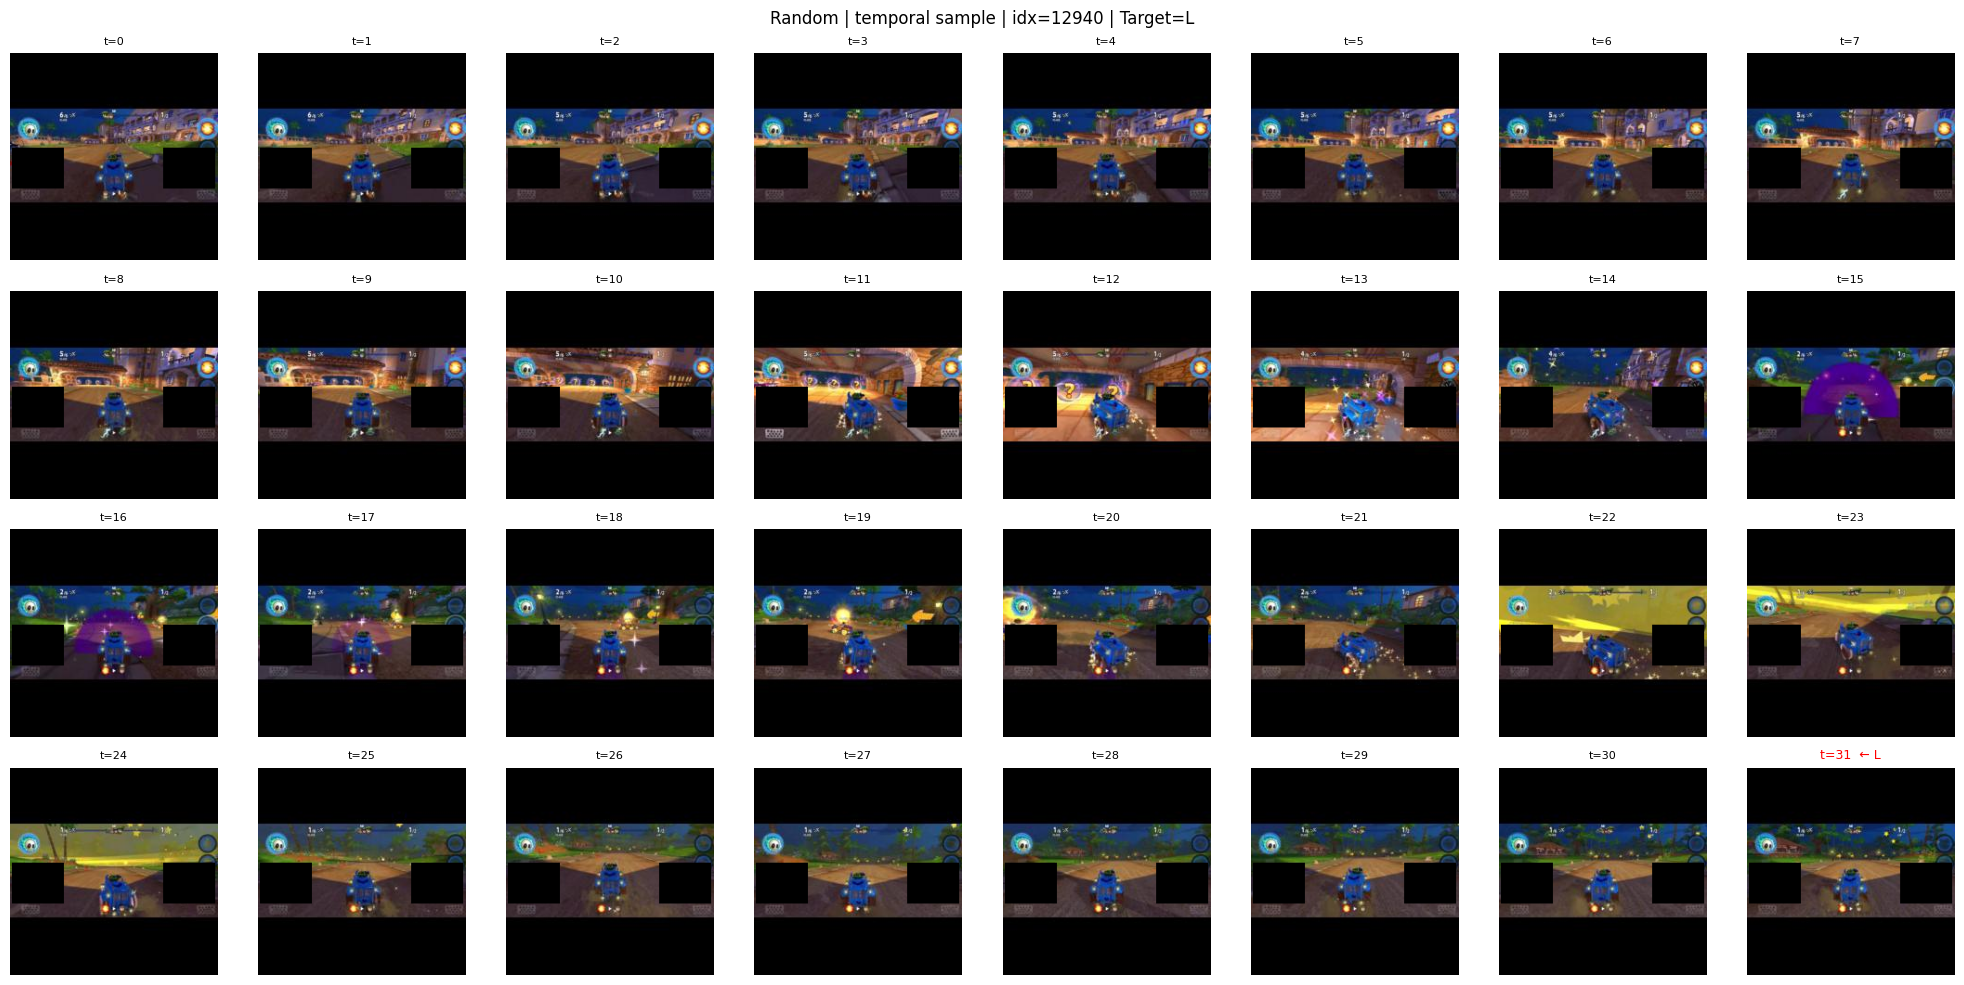

In [4]:
# Deterministic: first sample from Dataset (anchor index 0 in epoch_indices)
visualize_sequence_torch(train_ds1, random_sample=True, max_frames_to_show=32, dataset_index=6)


In [6]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights


class FrameViT(nn.Module):
    """
    Per-frame ViT feature extractor.

    Input:  (B, 3, 224, 224) in [0,1] float32
    Output: (B, out_dim) (default 256)

    Uses pretrained ViT-B/16 and returns a pooled embedding.
    """
    def __init__(self, out_dim=256, freeze_backbone=False):
        super().__init__()

        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.backbone = vit_b_16(weights=weights)

        # Use ImageNet normalization values from the weights metadata
        mean = weights.transforms().mean
        std = weights.transforms().std
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))

        # Replace ViT classification head with identity to get features
        # torchvision ViT has `heads` (a Sequential). We want features instead of logits.
        self.backbone.heads = nn.Identity()

        # ViT-B/16 embedding dim is 768
        vit_dim = 768
        self.proj = nn.Linear(vit_dim, out_dim)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        """
        x: (B,3,224,224) float in [0,1]
        """
        # ImageNet normalize
        x = (x - self.mean) / (self.std + 1e-6)

        # backbone now returns (B, 768) because heads=Identity
        feats = self.backbone(x)  # (B,768)

        feats = self.proj(feats)  # (B,out_dim)
        return feats


import torch
import torch.nn as nn
import torch.nn.functional as F


class ViTLSTMBinaryMove(nn.Module):
    """
    Binary classifier: Move vs No-move

    Input:  (B, T, 3, H, W)  where H=W=224
    Output: logit (B,) where sigmoid(logit) = P(move=1)
    """
    def __init__(
        self,
        seq_len=128,
        image_size=(224, 224),
        lstm_units=256,
        dropout=0.2,
        bidirectional=False,
        frame_encoder=None,      # FrameViT by default
        vit_out_dim=256,
        freeze_vit=False,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.image_size = image_size
        self.lstm_units = lstm_units
        self.bidirectional = bidirectional

        # Use ViT frame encoder
        self.frame_encoder = frame_encoder if frame_encoder is not None else FrameViT(
            out_dim=vit_out_dim,
            freeze_backbone=freeze_vit
        )

        self.lstm = nn.LSTM(
            input_size=vit_out_dim,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0,
        )

        lstm_out_dim = lstm_units * (2 if bidirectional else 1)

        self.fc_mid = nn.Linear(lstm_out_dim, 128)
        self.drop = nn.Dropout(dropout)
        self.fc_out = nn.Linear(128, 1)

    def forward(self, x):
        # x: (B,T,3,H,W)
        B, T, C, H, W = x.shape
        assert (H, W) == self.image_size, f"Expected {self.image_size}, got {(H,W)}"

        x = x.reshape(B * T, C, H, W)
        feats = self.frame_encoder(x)          # (B*T, vit_out_dim)
        feats = feats.reshape(B, T, -1)        # (B,T,vit_out_dim)

        out, _ = self.lstm(feats)
        last = out[:, -1, :]                   # (B,lstm_out_dim)

        h = F.relu(self.fc_mid(last))
        # h = self.drop(h)  # optional
        logit = self.fc_out(h).squeeze(-1)     # (B,)
        return logit


model = ViTLSTMBinaryMove(
    seq_len=seq_len,
    image_size=(224, 224),
    lstm_units=256,
    dropout=0.2,
    bidirectional=False,
    vit_out_dim=256,
    freeze_vit=True,   # set True if you want to train only LSTM+head first
)

print(model)


ViTLSTMBinaryMove(
  (frame_encoder): FrameViT(
    (backbone): VisionTransformer(
      (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (encoder): Encoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (layers): Sequential(
          (encoder_layer_0): EncoderBlock(
            (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (self_attention): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (dropout): Dropout(p=0.0, inplace=False)
            (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): MLPBlock(
              (0): Linear(in_features=768, out_features=3072, bias=True)
              (1): GELU(approximate='none')
              (2): Dropout(p=0.0, inplace=False)
              (3): Linear(in_features=3072, out_features=768, bias=True)
              (4): Dropout(p=0.0, inplace=False)
          

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FrameCNN(nn.Module):
    """
    Per-frame CNN feature extractor that mirrors your Keras frame_cnn() block.

    Input:  (B, 3, H, W)
    Output: (B, 256)
    """
    def __init__(self, in_ch=3, dropout=0.2):
        super().__init__()

        # Block 1
        self.conv1a = nn.Conv2d(in_ch, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)

        # GAP
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # FC head (512 -> 256)
        self.fc1 = nn.Linear(128, 512)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 256)

    def forward(self, x):
        # x: (B,3,H,W)
        x = self.conv1a(x)
        x = F.relu(x)
        x = self.conv1b(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2a(x)
        x = F.relu(x)
        x = self.conv2b(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3a(x)
        x = self.bn3a(x)
        x = F.relu(x)
        x = self.conv3b(x)
        x = self.bn3b(x)
        x = F.relu(x)

        x = self.gap(x)              # (B,128,1,1)
        x = x.flatten(1)             # (B,128)
        x = F.relu(self.fc1(x))      # (B,512)
        x = self.drop(x)
        x = F.relu(self.fc2(x))      # (B,256)
        return x


class CNNLSTMBinaryMove(nn.Module):
    """
    Binary classifier: Move vs No-move

    Input:  (B, T, 3, H, W)
    Output: move_logit (B,)  where sigmoid(logit) = P(move=1)
    """
    def __init__(
        self,
        seq_len=128,
        image_size=(224, 224),
        lstm_units=256,
        dropout=0.2,
        bidirectional=False,
        frame_cnn=None,   # optionally pass your existing FrameCNN
    ):
        super().__init__()
        self.seq_len = seq_len
        self.image_size = image_size
        self.lstm_units = lstm_units
        self.bidirectional = bidirectional

        # reuse your FrameCNN
        self.frame_cnn = frame_cnn if frame_cnn is not None else FrameCNN(in_ch=3, dropout=dropout)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0,
        )

        lstm_out_dim = lstm_units * (2 if bidirectional else 1)

        self.fc_mid = nn.Linear(lstm_out_dim, 128)
        self.drop = nn.Dropout(dropout)
        self.fc_out = nn.Linear(128, 1)  # <-- single logit

    def forward(self, x):
        # x: (B,T,3,H,W)
        B, T, C, H, W = x.shape

        x = x.reshape(B * T, C, H, W)
        feats = self.frame_cnn(x)          # (B*T,256)
        feats = feats.reshape(B, T, 256)   # (B,T,256)

        out, _ = self.lstm(feats)
        last = out[:, -1, :]               # (B,lstm_out_dim)

        h = F.relu(self.fc_mid(last))
        #h = self.drop(h)
        logit = self.fc_out(h).squeeze(-1) # (B,)
        return logit
    

# ---- Build model (equivalent to your build_cnn_lstm_for_frames) ----
model = CNNLSTMBinaryMove(
    seq_len=seq_len,
    image_size=(224, 224),
    lstm_units=256,
    dropout=0.2,
    bidirectional=False,
)
print(model)


CNNLSTMBinaryMove(
  (frame_cnn): FrameCNN(
    (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3b): BatchNorm2d

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FrameCNN(nn.Module):
    """
    Per-frame CNN feature extractor that mirrors your Keras frame_cnn() block.

    Input:  (B, 3, H, W)
    Output: (B, 256)
    """
    def __init__(self, in_ch=3, dropout=0.2):
        super().__init__()

        # Block 1
        self.conv1a = nn.Conv2d(in_ch, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)

        # GAP
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # FC head (512 -> 256)
        self.fc1 = nn.Linear(128, 512)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 256)

    def forward(self, x):
        # x: (B,3,H,W)
        x = self.conv1a(x)
        x = F.relu(x)
        x = self.conv1b(x)
        #x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2a(x)
        x = F.relu(x)
        x = self.conv2b(x)
        #x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3a(x)
        #x = self.bn3a(x)
        x = F.relu(x)
        x = self.conv3b(x)
        #x = self.bn3b(x)
        x = F.relu(x)

        x = self.gap(x)              # (B,128,1,1)
        x = x.flatten(1)             # (B,128)
        x = F.relu(self.fc1(x))      # (B,512)
        x = self.drop(x)
        x = F.relu(self.fc2(x))      # (B,256)
        return x


class CNNLSTM3Class(nn.Module):
    """
    Mirrors your Keras model:

      Input:  (B, T, 3, H, W)
      Frame CNN -> (B,T,256)
      LSTM -> (B,lstm_units) using last output
      Dense 128 + Dropout
      Classifier -> logits (B,n_classes)

    Use CrossEntropyLoss (expects logits).
    """
    def __init__(
        self,
        seq_len=128,
        image_size=(224, 224),
        n_classes=3,
        lstm_units=256,
        dropout=0.2,
        bidirectional=False,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.image_size = image_size
        self.n_classes = n_classes
        self.lstm_units = lstm_units
        self.bidirectional = bidirectional

        self.frame_cnn = FrameCNN(in_ch=3, dropout=dropout)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0,  # PyTorch LSTM dropout works only when num_layers > 1
        )

        lstm_out_dim = lstm_units * (2 if bidirectional else 1)

        self.fc_mid = nn.Linear(lstm_out_dim, 128)
        self.drop = nn.Dropout(dropout)
        self.fc_out = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B,T,3,H,W)
        B, T, C, H, W = x.shape

        # Flatten time into batch for CNN: (B*T,3,H,W)
        x = x.reshape(B * T, C, H, W)
        feats = self.frame_cnn(x)          # (B*T,256)

        # Restore time: (B,T,256)
        feats = feats.reshape(B, T, 256)

        # LSTM over time
        out, (h_n, c_n) = self.lstm(feats)

        # Last time-step output (equivalent to return_sequences=False)
        last = out[:, -1, :]               # (B, lstm_out_dim)

        x = F.relu(self.fc_mid(last))      # (B,128)
        x = self.drop(x)
        logits = self.fc_out(x)            # (B,n_classes)
        return logits


# ---- Build model (equivalent to your build_cnn_lstm_for_frames) ----
seq_len = seq_len  # keep your existing variable
model = CNNLSTM3Class(
    seq_len=seq_len,
    image_size=(224, 224),
    n_classes=3,
    lstm_units=256,
    dropout=0.2,
    bidirectional=False,
)
print(model)


CNNLSTM3Class(
  (frame_cnn): FrameCNN(
    (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3b): BatchNorm2d(128

In [6]:

# ---- Loss + optimizer (equivalent compile) ----
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # ~L2
criterion = nn.BCEWithLogitsLoss()  # sparse labels (0/1/2), logits input

In [7]:
import time
import sys


def keras_progress_bar(
    step,
    total_steps,
    loss,
    acc,
    elapsed,
    bar_width=30,
    prefix="",
    eta=None,
):
    frac = step / total_steps
    filled = int(bar_width * frac)
    bar = "=" * filled + ">" + "." * (bar_width - filled - 1)

    msg = (
        f"\r{prefix}"
        f"{step}/{total_steps} "
        f"[{bar}] "
        f"- {elapsed:.0f}s"
    )

    if eta is not None:
        msg += f" - ETA: {eta}"

    msg += f" - loss: {loss:.4g} - accuracy: {acc:.4f}"
    sys.stdout.write(msg)
    sys.stdout.flush()


In [8]:
import time
import torch


def train_model(
    model,
    train_loaders,   # list of train loaders
    val_loader,
    optimizer,
    criterion,       # nn.BCEWithLogitsLoss(...)
    epochs=10,
    device="cuda" if torch.cuda.is_available() else "cpu",
    none_class_index=1,      # your original labels: 0=L,1=None,2=R
    threshold=0.5,           # prob threshold for move
):
    """
    Train a binary Move/No-move classifier.

    Assumes your dataset still returns y in {0,1,2} (Left,None,Right).
    We convert to:
      y_move = 1 if y != none_class_index else 0

    Model output:
      logits_move: shape (B,) or (B,1) (we squeeze to (B,))
    """
    model.to(device)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # -------------------------
        # TRAIN
        # -------------------------
        model.train()

        for dl in train_loaders:
            if hasattr(dl.dataset, "on_epoch_start"):
                dl.dataset.on_epoch_start()

        total_steps = sum(len(dl) for dl in train_loaders)
        step = 0

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        start_time = time.time()

        for loader in train_loaders:
            for X, y in loader:
                step += 1

                X = X.to(device)          # (B,T,3,H,W)
                y = y.to(device)          # (B,) in {0,1,2}

                # Convert to binary: move=1 if not None else 0
                y_move = (y != none_class_index).float()   # (B,) float for BCE

                optimizer.zero_grad(set_to_none=True)

                logits = model(X)  # (B,) or (B,1)
                if logits.ndim == 2 and logits.shape[1] == 1:
                    logits = logits.squeeze(1)
                else:
                    logits = logits.view(-1)

                loss = criterion(logits, y_move)
                loss.backward()
                optimizer.step()

                # stats
                B = y_move.numel()
                running_loss += loss.item() * B

                probs = torch.sigmoid(logits)
                preds = (probs >= threshold).long()        # 0/1
                gts = y_move.long()

                running_correct += (preds == gts).sum().item()
                running_total += B

                elapsed = time.time() - start_time
                acc = running_correct / max(1, running_total)

                # ETA
                steps_left = total_steps - step
                if step > 1:
                    sec_per_step = elapsed / step
                    eta = time.strftime("%M:%S", time.gmtime(steps_left * sec_per_step))
                else:
                    eta = None

                keras_progress_bar(
                    step=step,
                    total_steps=total_steps,
                    loss=running_loss / max(1, running_total),
                    acc=acc,
                    elapsed=elapsed,
                    eta=eta,
                )

        print()

        train_loss = running_loss / max(1, running_total)
        train_acc = running_correct / max(1, running_total)

        # -------------------------
        # VALIDATION
        # -------------------------
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(device)
                y = y.to(device)

                y_move = (y != none_class_index).float()

                logits = model(X)
                if logits.ndim == 2 and logits.shape[1] == 1:
                    logits = logits.squeeze(1)
                else:
                    logits = logits.view(-1)

                loss = criterion(logits, y_move)

                B = y_move.numel()
                val_loss_sum += loss.item() * B

                probs = torch.sigmoid(logits)
                preds = (probs >= threshold).long()
                gts = y_move.long()

                val_correct += (preds == gts).sum().item()
                val_total += B

        val_loss = val_loss_sum / max(1, val_total)
        val_acc = val_correct / max(1, val_total)

        epoch_time = time.time() - start_time

        print(
            f"{total_steps}/{total_steps} "
            f"[==============================] "
            f"- {epoch_time:.0f}s "
            f"- loss: {train_loss:.4g} "
            f"- accuracy: {train_acc:.4f} "
            f"- val_loss: {val_loss:.4g} "
            f"- val_accuracy: {val_acc:.4f}"
        )


In [7]:
from pathlib import Path
from time import time
from datetime import timedelta
from typing import Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

# ---------------------------
# Metrics
# ---------------------------
def binary_metrics_from_logits(logits: torch.Tensor, y: torch.Tensor):
    """
    logits: (B,)
    y:      (B,) long {0,1}
    returns: acc, auroc (may be None if degenerate)
    """
    with torch.no_grad():
        probs = torch.sigmoid(logits).detach()
        preds = (probs >= 0.5).long()
        acc = (preds == y).float().mean().item()

        # AUROC (naive implementation to avoid extra deps)
        # Degenerate cases return None
        try:
            pos = probs[y == 1]
            neg = probs[y == 0]
            if pos.numel() == 0 or neg.numel() == 0:
                auroc = None
            else:
                # Probability that a random pos > random neg
                # (Mann–Whitney U statistic)
                auroc = (pos.view(-1, 1) > neg.view(1, -1)).float().mean().item()
        except Exception:
            auroc = None
        return acc, auroc

# ---------------------------
# Train / Val loops
# ---------------------------
def run_epoch(
    model: nn.Module,
    loader,
    optimizer: Optional[optim.Optimizer],
    scaler: Optional[GradScaler],
    device: torch.device,
    criterion: nn.Module,
    max_grad_norm: Optional[float] = 1.0,
    train: bool = True,
    epoch: int = 1,
    num_epochs: int = 1,
    desc_tag: str = "train",
):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    seen = 0
    running_acc = 0.0
    auroc_buffer = []  # collect batch AUROCs where defined

    pbar = tqdm(
        enumerate(loader, 1),
        total=len(loader),
        desc=f"Epoch {epoch}/{num_epochs} [{desc_tag}]",
        ncols=120,
        unit="batch",
        leave=False
    )
    start_time = time()

    for step, batch in pbar:
        # x = batch["x"].to(device, non_blocking=True)     # (B,T,C,H,W)
        # y = batch["y"].to(device, non_blocking=True).long()  # (B,)
        x, y = batch
        x = x.to(device)          # (B,T,3,H,W)
        y = y.to(device)          # (B,) in {0,1,2}
        bsz = x.size(0)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):
            logits = model(x)                  # (B,)
            loss = criterion(logits, y.float())

        if train:
            if scaler is not None:
                scaler.scale(loss).backward()
                if max_grad_norm is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if max_grad_norm is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()

        # metrics
        acc, auroc = binary_metrics_from_logits(logits.detach(), y.detach())
        running_acc += acc * bsz
        if auroc is not None:
            auroc_buffer.append((auroc, bsz))

        running_loss += loss.item() * bsz
        seen += bsz

        elapsed = time() - start_time
        batches_left = len(loader) - step
        eta = timedelta(seconds=int(elapsed / max(step, 1) * batches_left))
        avg_loss = running_loss / max(seen, 1)
        avg_acc  = running_acc / max(seen, 1)
        if auroc_buffer:
            # weighted average by batch size
            num = sum(a * n for a, n in auroc_buffer)
            den = sum(n for _, n in auroc_buffer)
            avg_auc = num / den
            pbar.set_postfix_str(f"loss: {avg_loss:.4f}  acc: {avg_acc:.3f}  auc: {avg_auc:.3f}  ETA: {eta}")
        else:
            pbar.set_postfix_str(f"loss: {avg_loss:.4f}  acc: {avg_acc:.3f}  ETA: {eta}")

    # epoch aggregates
    epoch_loss = running_loss / max(seen, 1)
    epoch_acc  = running_acc / max(seen, 1)
    if auroc_buffer:
        num = sum(a * n for a, n in auroc_buffer)
        den = sum(n for _, n in auroc_buffer)
        epoch_auc = num / den
    else:
        epoch_auc = None

    return epoch_loss, epoch_acc, epoch_auc

# ---------------------------
# Orchestration
# ---------------------------
def fit(
    model: nn.Module,
    train_loader,
    val_loader: Optional[object],   # <-- now optional
    device: torch.device,
    num_epochs: int = 50,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    class_weight_pos: Optional[float] = None,
    save_path: Path = Path("charcoal_state.pt"),
    best_path: Path = Path("charcoal_best.pt"),
    max_grad_norm: Optional[float] = 1.0,
    scheduler_patience: int = 5,
):
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=scheduler_patience,
        factor=0.5
    )

    # Loss
    if class_weight_pos is not None and class_weight_pos > 0:
        pos_weight = torch.tensor([class_weight_pos], device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    scaler = GradScaler(enabled=torch.cuda.is_available())

    best_metric = float("inf")  # train or val depending on availability

    for epoch in range(1, num_epochs + 1):
        # -------------------- TRAIN --------------------
        train_loss, train_acc, train_auc = run_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            device,
            criterion,
            max_grad_norm=max_grad_norm,
            train=True,
            epoch=epoch,
            num_epochs=num_epochs,
            desc_tag="train",
        )

        # -------------------- VALIDATE (OPTIONAL) --------------------
        if val_loader is not None:
            with torch.no_grad():
                val_loss, val_acc, val_auc = run_epoch(
                    model,
                    val_loader,
                    optimizer=None,
                    scaler=None,
                    device=device,
                    criterion=criterion,
                    max_grad_norm=None,
                    train=False,
                    epoch=epoch,
                    num_epochs=num_epochs,
                    desc_tag="valid",
                )
            monitor_loss = val_loss
        else:
            val_loss = val_acc = val_auc = None
            monitor_loss = train_loss

        # -------------------- SAVE --------------------
        torch.save(model.state_dict(), save_path)

        if monitor_loss < best_metric:
            best_metric = monitor_loss
            torch.save(model.state_dict(), best_path)

        scheduler.step(monitor_loss)

        # -------------------- LOG --------------------
        if val_loader is not None:
            print(
                f"\nEpoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} acc={train_acc:.3f} auc={train_auc if train_auc is not None else float('nan'):.3f} | "
                f"val_loss={val_loss:.4f} acc={val_acc:.3f} auc={val_auc if val_auc is not None else float('nan'):.3f} | "
                f"best={best_metric:.4f}"
            )
        else:
            print(
                f"\nEpoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} acc={train_acc:.3f} auc={train_auc if train_auc is not None else float('nan'):.3f} | "
                f"best={best_metric:.4f}"
            )

    print(
        f"\nTraining complete. "
        f"Best metric={best_metric:.4f}. "
        f"Saved last -> {save_path}, best -> {best_path}"
    )


In [8]:
#load saved model weights
model_path = r"data\move.pt"
model.load_state_dict(torch.load(model_path))

C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_6880\2241516820.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [ ]:
fit(
    model=model,
    train_loader=train_loader1,
    val_loader=None,
    device='cuda',
    num_epochs=10,
    lr=3e-4,
    weight_decay=1e-4,
    class_weight_pos=None,     # or e.g., 1.5 if positives are rarer
    save_path=Path("data/move.pt"),
    best_path=Path("data/move_best.pt")
)

In [37]:
fit(
    model=model,
    train_loader=train_loader2,
    device='cuda',
    val_loader=None,          # no validation
    num_epochs=100,
    lr=3e-4,
    weight_decay=1e-4,
    class_weight_pos=None,     # or e.g., 1.5 if positives are rarer
    save_path=Path("data/move.pt"),
    best_path=Path("data/move_best.pt")
)

C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_43476\3417428209.py:175: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
Epoch 1/100 [train]:   0%|                                                                  | 0/6131 [00:00<?, ?batch/s]C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_43476\3417428209.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):



Epoch 001 | train_loss=0.5333 acc=0.732 auc=0.732 | best=0.5333



Epoch 002 | train_loss=0.5193 acc=0.741 auc=0.750 | best=0.5193


KeyboardInterrupt: 

In [18]:
from time import time
from datetime import timedelta
from typing import Optional, Tuple

import torch
import torch.nn as nn
from torch.cuda.amp import autocast
from tqdm import tqdm


def validate(
    model: nn.Module,
    val_loader,
    device: torch.device,
    criterion: Optional[nn.Module] = None,
    use_amp: Optional[bool] = None,
    epoch: int = 1,
    num_epochs: int = 1,
    desc_tag: str = "valid",
) -> Tuple[float, float, Optional[float]]:
    """
    Validate a binary classifier model.

    Args:
        model: nn.Module returning logits of shape (B,) or (B,1)
        val_loader: yields either (x,y) where x=(B,T,3,H,W) and y=(B,) in {0,1}
        device: torch.device
        criterion: optional loss function. If None, loss will be NaN.
        use_amp: if None, enables AMP when CUDA is available
        epoch/num_epochs/desc_tag: for tqdm description

    Returns:
        val_loss, val_acc, val_auc (auc can be None if degenerate)
    """
    model.eval()
    model.to(device)

    if use_amp is None:
        use_amp = torch.cuda.is_available()

    running_loss = 0.0
    running_acc = 0.0
    seen = 0
    auroc_buffer = []

    pbar = tqdm(
        enumerate(val_loader, 1),
        total=len(val_loader),
        desc=f"Epoch {epoch}/{num_epochs} [{desc_tag}]",
        ncols=120,
        unit="batch",
        leave=False,
    )
    start_time = time()

    with torch.no_grad():
        for step, batch in pbar:
            x, y = batch
            x = x.to(device)
            y = y.to(device).long()  # expects {0,1}
            bsz = x.size(0)

            with autocast(enabled=use_amp):
                logits = model(x)
                # allow (B,1) outputs too
                if logits.ndim == 2 and logits.size(1) == 1:
                    logits = logits.squeeze(1)

                if criterion is not None:
                    loss = criterion(logits, y.float())
                else:
                    loss = None

            # metrics
            acc, auroc = binary_metrics_from_logits(logits.detach(), y.detach())
            running_acc += acc * bsz
            if auroc is not None:
                auroc_buffer.append((auroc, bsz))

            if loss is not None:
                running_loss += loss.item() * bsz

            seen += bsz

            elapsed = time() - start_time
            batches_left = len(val_loader) - step
            eta = timedelta(seconds=int(elapsed / max(step, 1) * batches_left))

            avg_loss = (running_loss / max(seen, 1)) if criterion is not None else float("nan")
            avg_acc = running_acc / max(seen, 1)

            if auroc_buffer:
                num = sum(a * n for a, n in auroc_buffer)
                den = sum(n for _, n in auroc_buffer)
                avg_auc = num / den
                pbar.set_postfix_str(f"loss: {avg_loss:.4f}  acc: {avg_acc:.3f}  auc: {avg_auc:.3f}  ETA: {eta}")
            else:
                pbar.set_postfix_str(f"loss: {avg_loss:.4f}  acc: {avg_acc:.3f}  ETA: {eta}")

    val_loss = (running_loss / max(seen, 1)) if criterion is not None else float("nan")
    val_acc = running_acc / max(seen, 1)
    if auroc_buffer:
        num = sum(a * n for a, n in auroc_buffer)
        den = sum(n for _, n in auroc_buffer)
        val_auc = num / den
    else:
        val_auc = None

    return val_loss, val_acc, val_auc


In [19]:

val_loss, val_acc, val_auc = validate(model, val_loader, 'cuda', criterion=criterion, epoch=1, num_epochs=50)
print(val_loss, val_acc, val_auc)

Epoch 1/50 [valid]:   0%|                                                                   | 0/3197 [00:00<?, ?batch/s]C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_43476\1744694201.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
                                                                                                                        

0.6985588897855617 0.6086072385319284 0.7306738863607997


In [21]:
fit(
    model=model,
    train_loader=train_loader1,
    val_loader=None,
    device='cuda',
    num_epochs=10,
    lr=3e-4,
    weight_decay=1e-4,
    class_weight_pos=None,     # or e.g., 1.5 if positives are rarer
    save_path=Path("data/move.pt"),
    best_path=Path("data/move_best.pt")
)

C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_43476\3417428209.py:175: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
Epoch 1/10 [train]:   0%|                                                                   | 0/3826 [00:00<?, ?batch/s]C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_43476\3417428209.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


KeyboardInterrupt: 

In [ ]:
train_model(
    model=model,
    train_loaders=[train_loader1],
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=100,
)



Epoch 1/100
3826/3826 [==============================>] - 1486s - ETA: 00:00 - loss: 0.693 - accuracy: 0.5100


In [43]:
#save the model
torch.save(model.state_dict(), "data\cnn_lstm_model.pth")

In [24]:
import random
import torch
import matplotlib.pyplot as plt
import numpy as np


def predict_random_sequence(
    model,
    val_ds,
    device="cpu",
    none_class_index=1,
    threshold=0.5,
):
    """
    Randomly pick one temporal window from val_ds and show
    GT Move/No-move vs predicted Move/No-move.

    Displays the *last frame* in the sequence window.
    """

    model.eval()
    model.to(device)

    # -----------------------------
    # Pick random sample
    # -----------------------------
    idx = random.randint(0, len(val_ds) - 1)
    sample = val_ds[idx]

    # Handle dataset variants safely
    if isinstance(sample, (list, tuple)) and len(sample) >= 2:
        X, y = sample[0], sample[1]
        extra = sample[2] if len(sample) > 2 else None
    else:
        raise ValueError("Dataset item must return at least (X, y)")

    # Convert GT to binary move label
    # y: 0=Left, 1=None, 2=Right
    gt_move = int(y.item() != none_class_index)

    # X: (T,3,H,W) -> (1,T,3,H,W)
    Xb = X.unsqueeze(0).to(device)

    # -----------------------------
    # Model inference
    # -----------------------------
    with torch.no_grad():
        logits = model(Xb)
        if logits.ndim == 2 and logits.shape[1] == 1:
            logits = logits.squeeze(1)
        else:
            logits = logits.view(-1)

        prob_move = torch.sigmoid(logits)[0].item()
        pred_move = int(prob_move >= threshold)

    # -----------------------------
    # Visualization
    # -----------------------------
    last_frame = X[-1].permute(1, 2, 0).cpu().numpy()
    last_frame = np.clip(last_frame, 0.0, 1.0)

    gt_label = "Move" if gt_move == 1 else "No-move"
    pred_label = "Move" if pred_move == 1 else "No-move"

    plt.figure(figsize=(5, 5))
    plt.imshow(last_frame)
    plt.axis("off")

    title = (
        f"GT: {gt_label} | Pred: {pred_label}\n"
        f"P(move) = {prob_move:.3f}"
    )
    if extra is not None:
        title = f"{extra}\n{title}"

    plt.title(title, fontsize=10)
    plt.show()

    # -----------------------------
    # Console output
    # -----------------------------
    print(f"Dataset index : {idx}")
    if extra is not None:
        print(f"Extra        : {extra}")
    print(f"GT move      : {gt_move} ({gt_label})")
    print(f"Pred move    : {pred_move} ({pred_label})")
    print(f"P(move)      : {prob_move:.4f}")


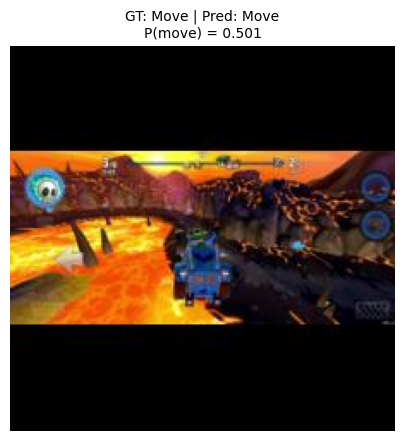

Dataset index : 27083
GT move      : 1 (Move)
Pred move    : 1 (Move)
P(move)      : 0.5014


In [36]:
predict_random_sequence(model, val_ds, device="cuda")